In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # matplotlib and seaborn are for visualization.
import seaborn as sns

# Load dataset
df = pd.read_csv('C:\Git Projects\ML-Projects/heart_attack_youngsters_india.csv')

# Quick look
df.head()


<>:8: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:8: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\chanu\AppData\Local\Temp\ipykernel_9716\2482646444.py:8: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  df = pd.read_csv('C:\Git Projects\ML-Projects/heart_attack_youngsters_india.csv')


,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Stress Level,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood
0,30,Male,East,Urban,Middle,Never,Regularly,Non-Vegetarian,Sedentary,3,...,High,177.0/63.1,82,Normal,Non-anginal,183,No,94.1,58,No
1,24,Female,East,Urban,Low,Occasionally,Occasionally,Non-Vegetarian,Sedentary,15,...,High,137.5/110.7,76,Normal,Non-anginal,118,No,97.1,341,No
2,24,Female,North,Urban,Low,Occasionally,Occasionally,Vegan,High,15,...,Low,138.3/76.6,86,Normal,Typical,164,No,92.7,373,Yes
3,27,Male,East,Urban,Middle,Occasionally,Never,Vegetarian,Sedentary,6,...,Medium,177.1/90.0,106,Normal,Non-anginal,188,No,98.4,102,Yes
4,21,Female,West,Rural,Low,Occasionally,Occasionally,Vegetarian,Moderate,4,...,Low,130.7/108.8,73,Normal,Atypical,216,No,94.9,235,No


In [3]:
# Check data types and missing values
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       10000 non-null  int64  
 1   Gender                                    10000 non-null  str    
 2   Region                                    10000 non-null  str    
 3   Urban/Rural                               10000 non-null  str    
 4   SES                                       10000 non-null  str    
 5   Smoking Status                            10000 non-null  str    
 6   Alcohol Consumption                       10000 non-null  str    
 7   Diet Type                                 10000 non-null  str    
 8   Physical Activity Level                   10000 non-null  str    
 9   Screen Time (hrs/day)                     10000 non-null  int64  
 10  Sleep Duration (hrs/day)                  1000

Age                                         0
Gender                                      0
Region                                      0
Urban/Rural                                 0
SES                                         0
Smoking Status                              0
Alcohol Consumption                         0
Diet Type                                   0
Physical Activity Level                     0
Screen Time (hrs/day)                       0
Sleep Duration (hrs/day)                    0
Family History of Heart Disease             0
Diabetes                                    0
Hypertension                                0
Cholesterol Levels (mg/dL)                  0
BMI (kg/m²)                                 0
Stress Level                                0
Blood Pressure (systolic/diastolic mmHg)    0
Resting Heart Rate (bpm)                    0
ECG Results                                 0
Chest Pain Type                             0
Maximum Heart Rate Achieved       

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
#It scales numeric features so that they have mean = 0 and standard deviation = 1

# Fill missing numeric values only
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Encode categorical features if any
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Scale numerical features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

df_scaled.head()


C:\Users\chanu\AppData\Local\Temp\ipykernel_9716\3425679690.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Stress Level,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood
0,0.658116,0.851829,-0.856088,0.830518,1.080190,-0.894432,2.240201,-0.964917,0.911656,-0.975003,...,-1.339736,1.598445,-0.432710,0.417445,0.436192,0.665560,-0.331293,-0.291598,-1.684605,-0.505931
1,-0.503778,-0.989964,-0.856088,0.830518,-0.253872,0.382051,0.747828,-0.964917,0.911656,1.618837,...,-1.339736,-0.077187,-0.779183,0.417445,0.436192,-1.189871,-0.331293,0.748918,0.512266,-0.505931
2,-0.503778,-0.989964,-0.273557,0.830518,-0.253872,0.382051,0.747828,0.093803,-2.092647,1.618837,...,-0.137100,-0.039382,-0.201728,0.417445,1.328382,0.123203,-0.331293,-0.777172,0.760676,1.976555
3,0.077169,0.851829,-0.856088,0.830518,1.080190,0.382051,-0.744545,1.152522,0.911656,-0.326543,...,1.065535,1.605446,0.953182,0.417445,0.436192,0.808286,-0.331293,1.199809,-1.343042,1.976555
4,-1.084725,-0.989964,1.474037,-1.204068,-0.253872,0.382051,0.747828,1.152522,-0.590496,-0.758849,...,-0.137100,-0.378569,-0.952419,0.417445,-0.455998,1.607549,-0.331293,-0.014127,-0.310590,-0.505931


In [5]:
from scipy.spatial.distance import pdist, squareform

# Euclidean distance
euclidean_dist = pd.DataFrame(squareform(pdist(df_scaled, metric='euclidean')))
euclidean_dist.head()

# Euclidean distance = straight-line distance in n-dimensional space.

# pdist computes pairwise distances; squareform converts to a square distance matrix.

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,0.000000,6.070184,8.368094,6.495044,7.268085,7.574664,8.071061,6.103166,7.100270,7.184103,...,8.020962,7.717878,7.755010,5.944016,7.007153,7.337961,7.474541,7.770378,8.455950,6.015137
1,6.070184,0.000000,6.933310,6.551901,6.670609,7.801705,7.638839,4.885703,6.118692,6.519277,...,6.512765,7.025752,5.999920,6.954800,5.426355,6.646563,5.848626,7.064430,6.746141,7.350839
2,8.368094,6.933310,0.000000,7.730307,6.657523,7.726655,7.184768,6.689586,7.749246,8.008368,...,7.125742,7.473602,7.971597,7.865038,6.948575,7.458330,6.601844,6.707791,6.991347,8.760513
3,6.495044,6.551901,7.730307,0.000000,7.195335,7.270598,7.903473,6.786974,7.124553,7.863102,...,7.329098,6.419095,7.189263,8.455098,6.592680,7.432638,6.476974,7.634013,7.703879,6.689185
4,7.268085,6.670609,6.657523,7.195335,0.000000,6.242822,7.082449,6.147088,4.725232,6.823216,...,5.964397,5.118756,6.653527,6.532383,5.924472,7.118323,6.288709,6.470262,6.656634,6.777995


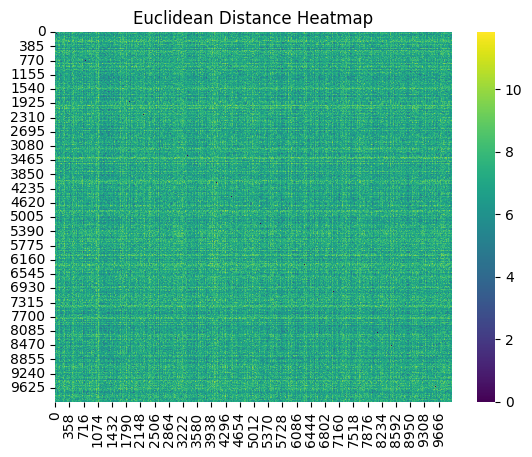

In [6]:
sns.heatmap(euclidean_dist, cmap='viridis')
plt.title('Euclidean Distance Heatmap')
plt.show()


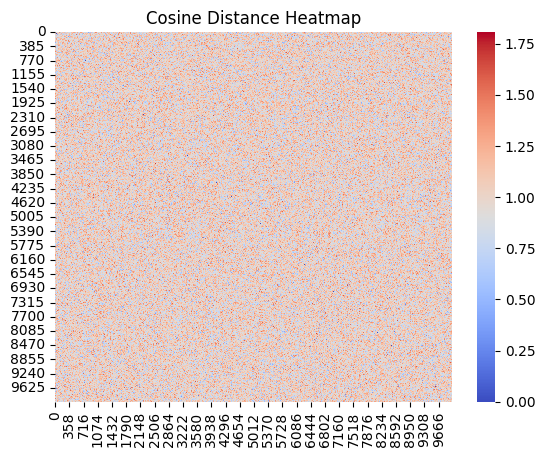

In [7]:
# Cosine distance
cosine_dist = pd.DataFrame(squareform(pdist(df_scaled, metric='cosine')))
sns.heatmap(cosine_dist, cmap='coolwarm')
plt.title('Cosine Distance Heatmap')
plt.show()

#Cosine distance measures the angle between vectors rather than magnitude.

#Useful for high-dimensional data.

Note: you may need to restart the kernel to use updated packages.


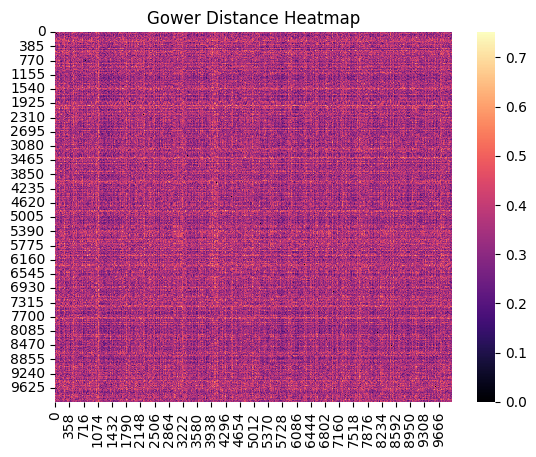

In [8]:
%pip install gower
#This installs the gower library in Python.

#Gower distance can handle mixed data types (numerical + categorical)

import gower

gower_dist = gower.gower_matrix(df)
sns.heatmap(gower_dist, cmap='magma')
plt.title('Gower Distance Heatmap')
plt.show()

#Normalizes numerical values and compares categorical values.

#Ideal if dataset has both numbers and categories.

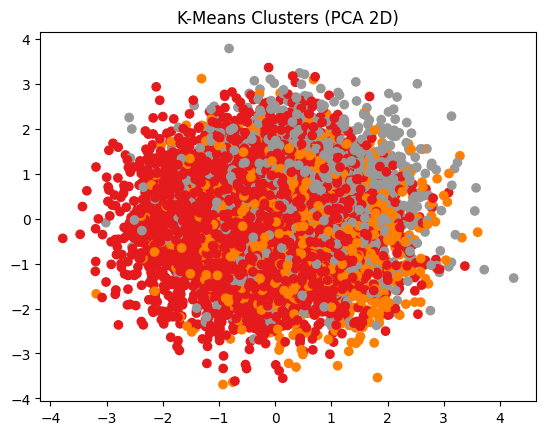

In [9]:
from sklearn.cluster import KMeans

# Choose number of clusters, e.g., 3
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['kmeans_labels'] = kmeans.fit_predict(df_scaled)

# Visualize clusters using first 2 principal components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled.drop('kmeans_labels', axis=1))

plt.scatter(pca_components[:,0], pca_components[:,1], c=df_scaled['kmeans_labels'], cmap='Set1')
plt.title('K-Means Clusters (PCA 2D)')
plt.show()

# K-Means clusters points into k groups based on distance.

# PCA reduces dimensions for easy 2D visualization.

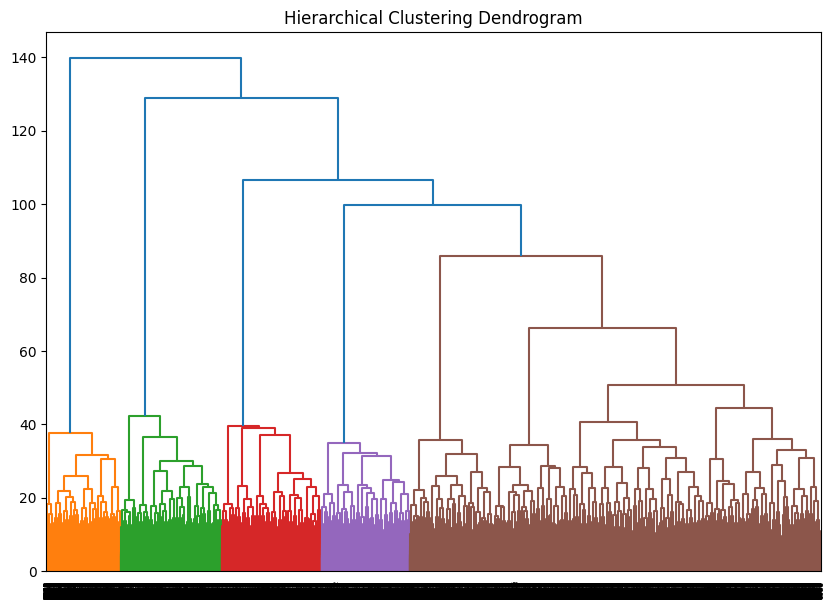

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Hierarchical clustering (Agglomerative)
linked = linkage(df_scaled.drop('kmeans_labels', axis=1), method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

# ward method minimizes variance within clusters.

# Dendrogram shows how clusters merge step by step.